Implement the non-parametric Locally Weighted Regression algorithm in order to fit data points. Select appropriate data set for your experiment and draw graphs

In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def gaussian_kernal(x, xi, tau):
    return np.exp(-np.linalg.norm(x - xi) ** 2 / (2 * tau ** 2))

In [3]:
def locally_weighted_regression(x, X, y, tau):
    m = X.shape[0]
    weights = np.zeros(m)
    
    for i in range(m):
        weights[i] = gaussian_kernal(x, X[i], tau)
    
    W = np.diag(weights)
    theta = np.linalg.inv(X.T @ W @ X) @ X.T @ W @ y
    return x @ theta

In [4]:
np.random.seed(42)
X = np.linspace(0, 2 * np.pi, 100)
y = np.sin(X) + 0.1 * np.random.randn(100)

X_bias = np.c_[np.ones(X.shape), X]

x_test = np.linspace(0, 2 * np.pi, 200)
x_test_bias = np.c_[np.ones(x_test.shape), x_test]

tau = 1

y_pred = np.array([locally_weighted_regression(xi, X_bias, y, tau) for xi in x_test_bias])

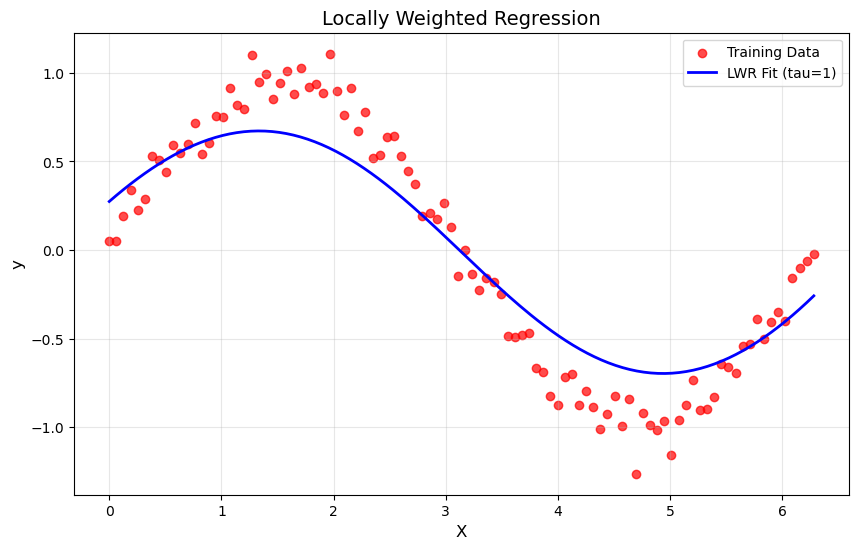

In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(X, y, color='red', label='Training Data', alpha=0.7)
plt.plot(x_test, y_pred, color='blue', label=f'LWR Fit (tau={tau})', linewidth=2)

plt.xlabel('X', fontsize=12)
plt.ylabel('y', fontsize=12)

plt.title('Locally Weighted Regression', fontsize=14)
plt.legend(fontsize=10)
plt.grid(alpha=0.3)

plt.show()